# Finalized Data Preprocessing and Model Creation

In [1]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


## Data Preprocessing

In [2]:
# All the imports that are needed for the models
import keras
import keras_tuner
import sklearn
import pandas as pd
import numpy as np
import tensorflow as tf
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from keras.layers import Dense
from keras.models import Sequential
from scikeras.wrappers import KerasRegressor
from keras.optimizers import SGD
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ARDRegression, LinearRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, precision_score, accuracy_score, recall_score
from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures

In [3]:
# This is our index of different timezone and major cities within each timezone in the form of a dictionary
cities_by_timezone = {
    'Pacific Time': ['Los Angeles', 'San Francisco Bay Area', 'Seattle', 'Portland', 'San Luis Obispo', 'Sacramento', 'San Diego', 'Santa Barbara', 'Camarillo', 'Fremont', 'Bend', 'Reno', 'Spokane', 'Las Vegas', 'Fresno'],
    'Mountain Time': ['Denver', 'Boulder', 'Salt Lake City', 'Missoula', 'Santa Fe', 'Phoenix', 'Lehi', 'Logan', 'Boise'],
    'Central Time': ['Austin', 'Chicago', 'Minneapolis', 'Milwaukee', 'Nashville', 'Dallas', 'Cincinnati', 'Columbus', 'Indianapolis', 'Nebraska City', 'Kansas City'],
    'Eastern Time': ['New York City', 'Boston', 'Atlanta', 'Ann Arbor', 'Miami', 'Detroit', 'Stamford', 'Washington DC', 'Philadelphia', 'Raleigh', 'Walnut', 'Madison', 'Dover', 'Burlington', 'Wilmington', 'Nashua', 'Baltimore', 'Tampa Bay']
}

def date_to_index(stock_data, date):
    date_col_stock_data = stock_data.index.to_pydatetime()
    for i in range(len(date_col_stock_data)):
        if date_col_stock_data[i] == date:
            return i
    return -1

def get_closest_available_date(stock_data, date):
    '''
    Get the closest available date 
    '''
    date_col_stock_data = stock_data.index.to_pydatetime()
    # date_col_stock_data = stock_data.reset_index()['Date']
    while date not in date_col_stock_data:
        date = date - timedelta(days = 1)
    return date


def weekly_price_diff(stock_data, week_end, period: int = 7):
    '''
    Finds the weekly price difference in NDXT index price in percents during last week before layoff date.

    @type stock_data: pandas DataFrame
    @param stock_data: original stock_data df
    @type week_end: datetime object
    @param week_end: layoff date in format datetime(YYYY,MM,DD)
    @type period: int
    @param period: number of days to look back, defaults to 7

    @returns price_diff: % of change in NDXT index price during last week before layoff date 
    '''
    if (week_end < datetime(2020, 1, 15)):
        return 0
    date_col_stock_data = stock_data.reset_index() 
    date_end_closest = get_closest_available_date(stock_data, week_end)
    date_start_closest = get_closest_available_date(stock_data, week_end - timedelta(days = period))
    price_start, price_end = stock_data['Open'][date_start_closest], stock_data['Open'][date_end_closest]
    price_diff = (price_end - price_start) / price_start * 100
    return price_diff

def str_to_datetime(dt_string):
    '''
    Converts a string to a formatted datetime representation of the date.

    @type dt_string: string
    @param dt_string: string to convert into a datetime object

    @returns datetime.strptime(dt_string, "%Y-%m-%d %H:%M:%S UTC"): datetime object that formats a date in a specific way
    '''
    return datetime.strptime(dt_string, "%Y-%m-%d %H:%M:%S UTC")

def get_timezone(city):
    '''
    Retrieve the timezone associated with a city.

    @type city: string
    @param city: name of city to retrieve timezone for
    @rtype: string, None
    @returns timezone: timezone of a city if in an index; otherwise, None
    '''
    for timezone, cities in cities_by_timezone.items():
        if city in cities:
            return timezone
    return None

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


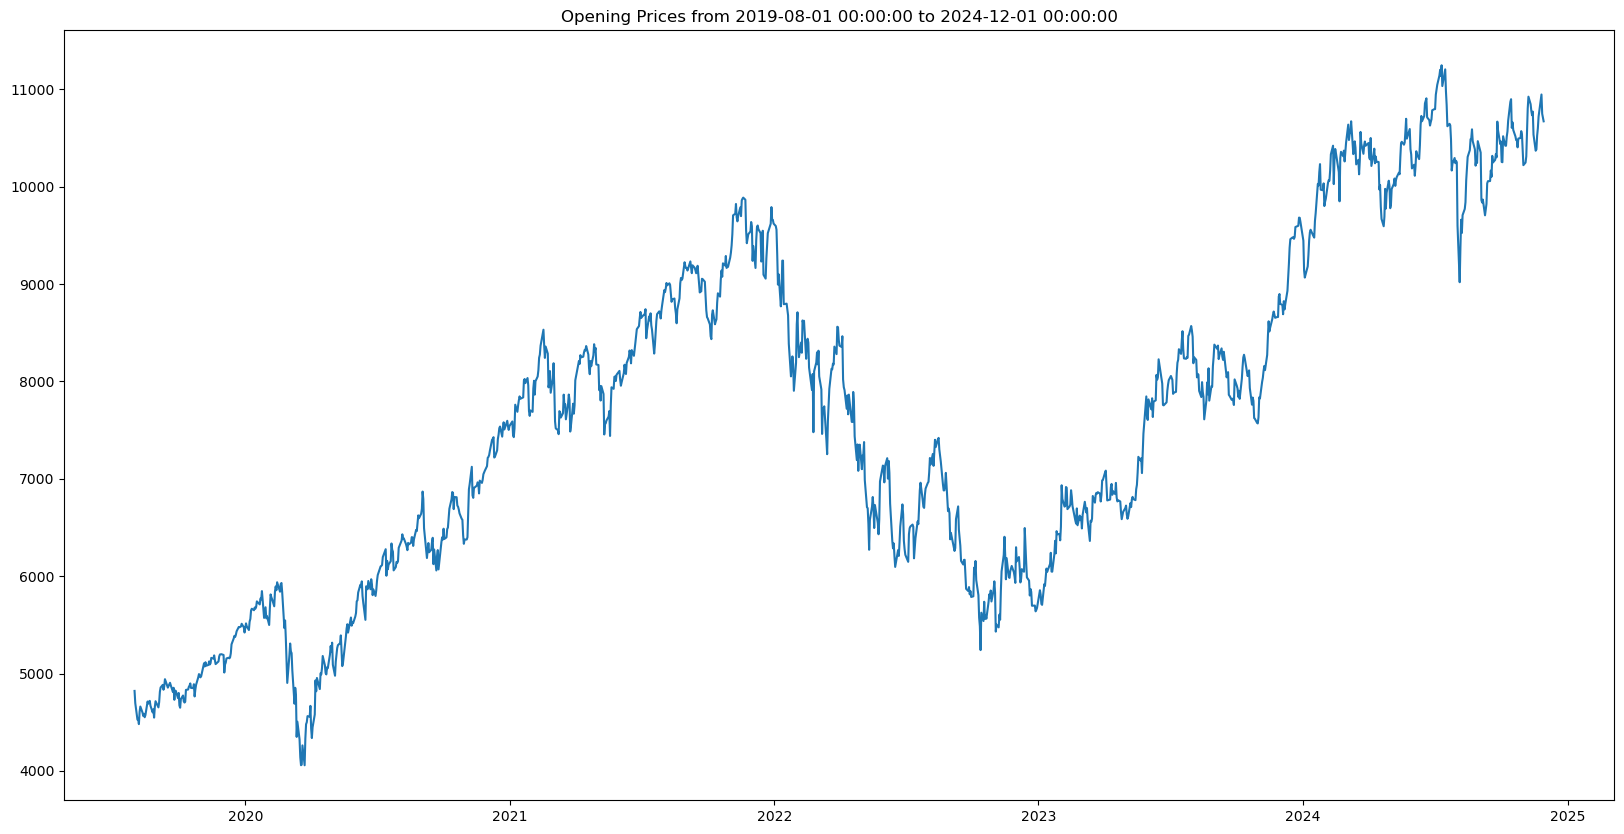

In [4]:
# Read in our stock data from August 1st, 2018 to December 1st, 2024
stock_data = yf.download('^NDXT', start=datetime(2019, 8, 1),
                         end=datetime(2024, 12, 1))
stock_data.to_csv('datasets/stock_data.csv', index = True, encoding='utf-8')

import os

# Create the 'datasets' directory if it doesn't exist
os.makedirs("datasets", exist_ok=True)

# Now save the file
stock_data.to_csv('datasets/stock_data.csv', index=True, encoding='utf-8')

# Visualize our preliminary stock data of opening prices
plt.figure(figsize = (20,10))
plt.title('Opening Prices from {} to {}'.format(datetime(2019, 8, 1),
                                                datetime(2024, 12, 1)))
plt.plot(stock_data['Open'])
plt.show()

In [5]:
import os

# Create 'datasets' directory if it doesn't exist
os.makedirs('datasets', exist_ok=True)

# Initialize the DataFrame
week_price_diff_df = pd.DataFrame(index=stock_data.index, columns=['price_diff'])

# Fill price_diff with exception handling for missing dates
for date in week_price_diff_df.index:
    try:
        week_price_diff_df.loc[date, 'price_diff'] = weekly_price_diff(stock_data, date)
    except KeyError:
        week_price_diff_df.loc[date, 'price_diff'] = None  # or 0 if preferred

# Add to stock_data
stock_data['price_diff'] = week_price_diff_df['price_diff']

# Save to CSV
stock_data.to_csv('datasets/stock_data.csv', index=True, encoding='utf-8')

# Display DataFrame
stock_data

Price,Close,High,Low,Open,Volume,price_diff
Ticker,^NDXT,^NDXT,^NDXT,^NDXT,^NDXT,
Date,,,,,,
2019-08-01,4762.810059,4924.919922,4726.339844,4821.149902,425800,0
2019-08-02,4655.560059,4712.990234,4629.250000,4695.549805,356000,0
2019-08-05,4469.970215,4534.649902,4434.459961,4525.939941,427900,0
2019-08-06,4531.810059,4562.890137,4481.229980,4530.689941,317500,0
2019-08-07,4550.560059,4563.459961,4470.759766,4480.180176,321600,0
...,...,...,...,...,...,...
2024-11-22,10772.679688,10780.580078,10667.809570,10720.280273,0,None
2024-11-25,10903.980469,10959.320312,10849.969727,10886.450195,0,None


In [6]:
layoff_data = pd.read_csv("/Applications/Dissertation/tech_layoffs_ml/datasets/tech_layoffs.csv")


In [7]:
layoff_data['Company'] = layoff_data['Company'].replace({'SaleSan Franciscoorce': 'Salesforce'})
layoff_data[layoff_data['Company'] == 'Salesforce']



,#,Company,Location_HQ,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in_$_mil,Year,lat,lng
470,1347,Salesforce,San Francisco Bay Area,USA,North America,8000,2023-01-04 00:00:00 UTC,10.0,80000,72000,Sales,Post-IPO,$65,2023,37.77493,-122.41942
608,1677,Salesforce,San Francisco Bay Area,USA,North America,1000,2022-11-07 00:00:00 UTC,1.0,100000,99000,Sales,Post-IPO,$65,2022,37.77493,-122.41942
1080,2674,Salesforce,San Francisco Bay Area,USA,North America,1000,2020-08-26 00:00:00 UTC,2.0,50000,49000,Sales,Post-IPO,$65,2020,37.77493,-122.41942


In [8]:
def weekly_price_diff(stock_data, date, period=14):
    # Ensure date is Timestamp
    date = pd.to_datetime(date)

    # Get the closest previous trading date
    if date not in stock_data.index:
        prev_dates = stock_data.index[stock_data.index <= date]
        if prev_dates.empty:
            return np.nan  # No prior data
        date = prev_dates[-1]

    future_dates = stock_data.index[stock_data.index > date]
    future_date = future_dates[future_dates <= date + pd.Timedelta(days=period)]
    if future_date.empty:
        return np.nan  # No future data
    future_date = future_date[-1]

    price_then = stock_data.loc[date]['Close']
    price_future = stock_data.loc[future_date]['Close']

    return price_future - price_then

In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder, OneHotEncoder



# Helper function: Get stock price difference for N days around the layoff date
def weekly_price_diff(stock_data, date, period=14):
    if not isinstance(date, pd.Timestamp):
        date = pd.to_datetime(date)
    start_date = date - timedelta(days=period//2)
    end_date = date + timedelta(days=period//2)

    try:
        start_price = stock_data.loc[stock_data.index >= start_date, "Close"].iloc[0]
        end_price = stock_data.loc[stock_data.index <= end_date, "Close"].iloc[-1]
        return end_price - start_price
    except IndexError:
        return np.nan  # If data is missing for that window

# ---- LOAD YOUR DATA FIRST ----
# layoff_data = pd.read_csv(...)  # Already loaded
# stock_data = pd.read_csv(...)   # Already loaded with Date as index
# stock_data.index = pd.to_datetime(stock_data.index)

# --- LAYOFF DATA CLEANING ---
layoff_data['Date_layoffs'] = layoff_data['Date_layoffs'].apply(str_to_datetime)
layoff_data['Company'] = layoff_data['Company'].replace({'SaleSan Franciscoorce': 'Salesforce'})
layoff_data.set_index('Date_layoffs', inplace=True)
layoff_data.sort_index(inplace=True)

# Filter for relevant data
layoff_data = layoff_data[(layoff_data['Continent'] == 'North America') &
                          (layoff_data['Country'] == 'USA') &
                          (layoff_data['Company_Size_before_Layoffs'] >= 10)]
layoff_data = layoff_data.drop(columns=["Company", "lat", "lng", "Continent", "Country", "#"])

# Add Region using timezone mapping
layoff_data['Region'] = layoff_data['Location_HQ'].map(get_timezone)

# Drop unused columns
layoff_data.drop(columns=["Location_HQ", "Company_Size_after_layoffs", "Laid_Off"], inplace=True)

# Label encoding
industry_encoder = LabelEncoder()
layoff_data['industry_encoded'] = industry_encoder.fit_transform(layoff_data['Industry'])

stage_encoder = LabelEncoder()
layoff_data['stage_encoded'] = stage_encoder.fit_transform(layoff_data['Stage'])

region_encoder = LabelEncoder()
layoff_data['Region_encoded'] = region_encoder.fit_transform(layoff_data['Region'])

# Drop original categorical columns
layoff_data.drop(columns=["Industry", "Stage", "Year", "Region"], inplace=True)

# Clean Money Raised column
layoff_data['Money_Raised_in_$_mil'] = layoff_data['Money_Raised_in_$_mil'].str.replace('$', '').astype(float) * 1_000_000

# Reset index to access date column
layoff_data.reset_index(inplace=True)

# Add stock_delta column using stock data
layoff_data['stock_delta'] = layoff_data['Date_layoffs'].apply(lambda x: weekly_price_diff(stock_data, x, period=14))

# Convert Date_layoffs to Unix timestamp
layoff_data['Date_layoffs_unix'] = layoff_data['Date_layoffs'].apply(lambda x: int(datetime.timestamp(x)))

# Drop original date column if not needed
layoff_data.drop(columns=['Date_layoffs'], inplace=True)

# Separate target
Y = layoff_data['Percentage']
layoff_data.drop(columns=['Percentage'], inplace=True)

# One-hot encode categorical columns
industry_onehot = OneHotEncoder(sparse_output=False, drop='first').fit_transform(layoff_data[['industry_encoded']])
stage_onehot = OneHotEncoder(sparse_output=False, drop='first').fit_transform(layoff_data[['stage_encoded']])
region_onehot = OneHotEncoder(sparse_output=False, drop='first').fit_transform(layoff_data[['Region_encoded']])

# Drop original encoded columns
layoff_data.drop(columns=['industry_encoded', 'stage_encoded', 'Region_encoded'], inplace=True)

# Final feature matrix
X = np.hstack((layoff_data.values, industry_onehot, stage_onehot, region_onehot))

In [10]:
# layoff_data.values, industry_onehot, stage_onehot, region_onehot
print("LAYOFF DATA VALS:", str(layoff_data.values[0]))
print("INDUSTRY ONEHOT:", str(industry_onehot[0]))
print("STAGE ONEHOT:", str(stage_onehot[0]))
print("REGION ONEHOT:", str(region_onehot[0]))

print("X:", str(X[0]))

LAYOFF DATA VALS: [ 5.00000000e+01  9.00000000e+07 -1.01912988e+03  1.58395140e+09]
INDUSTRY ONEHOT: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0.]
STAGE ONEHOT: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
REGION ONEHOT: [0. 0. 1. 0.]
X: [ 5.00000000e+01  9.00000000e+07 -1.01912988e+03  1.58395140e+09
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.

In [11]:
# Let's take a look at the shape of our features and our target
X.shape, Y.shape

((902, 51), (902,))

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("Training set shapes: X_train =", X_train.shape, ", Y_train =", y_train.shape)
print("Testing set shapes: X_test =", X_test.shape, ", Y_test =", y_test.shape)

Training set shapes: X_train = (721, 51) , Y_train = (721,)
Testing set shapes: X_test = (181, 51) , Y_test = (181,)


In [13]:
# Finally, let's take a look at our target!
Y

0       40.000000
1       10.000000
2       22.000000
3      100.000000
4       20.000000
          ...    
897      0.531915
898     13.333333
899     17.000000
900      5.000000
901     13.000000
Name: Percentage, Length: 902, dtype: float64

# Model 1: Basic Regression Models

For our first model, we want to determine whether or not our prediction model performs well with basic regression models. If it does, then it is a matter of choosing the correct regression model to analyze the data! If not, this means that we may need to look into more complex models, such as neural networks or decision trees.

In [14]:
mse_arr = []
linreg = LinearRegression()

X_train_df, y_train_df = pd.DataFrame(np.array(X_train)), pd.DataFrame(np.array(y_train))

linreg.fit(X_train_df, y_train_df)
yhat_train, yhat_test = linreg.predict(X_train), linreg.predict(X_test)

MSE_train, MSE_test = np.mean((y_train.values - yhat_train)**2), np.mean((y_test.values - yhat_test)**2)
mse_arr.append((MSE_train, MSE_test))
print(f"MSE_train: {MSE_train}\nMSE_test: {MSE_test}")

MSE_train: 484.9049452615973
MSE_test: 409.52617790656643


As we can see, while our Linear Regression model is not awful, it can certainly be a whole lot better. Looking into another form of regression models, Polynomial Regression, we can see how our error change as we add more degrees to our polynomial model

In [15]:
for k in range(2,5):
    # Create kth degree polynomial
    polyreg = PolynomialFeatures(k)

    # Transform features to fit polynomial model
    train_features = polyreg.fit_transform(X_train_df)
    test_features = polyreg.fit_transform(X_test)

    # Create polynomial regression
    polyreg = LinearRegression()
    polyreg.fit(train_features, y_train_df)

    # Get training and testing predictions
    yhat_train = polyreg.predict(train_features)
    yhat_test = polyreg.predict(test_features)

    # Display training and testing MSEs
    MSE_train = np.mean((y_train.values - yhat_train) ** 2)
    MSE_test = np.mean((y_test.values - yhat_test) ** 2)

    mse_arr.append((MSE_train, MSE_test))
    print(f'Degree: {k}\n    MSE_train: {MSE_train}\n    MSE_test: {MSE_test}')

Degree: 2
    MSE_train: 809.4391007128455
    MSE_test: 971.9054052931668
Degree: 3
    MSE_train: 526.7677914446597
    MSE_test: 543.551105901189
Degree: 4
    MSE_train: 558.4572645626278
    MSE_test: 554.0551070209634


If we graph our data, we can then see how jagged our error measures are for our training and testing data, and how our model may be underfitting due to the difference in complexity between the model and our data.

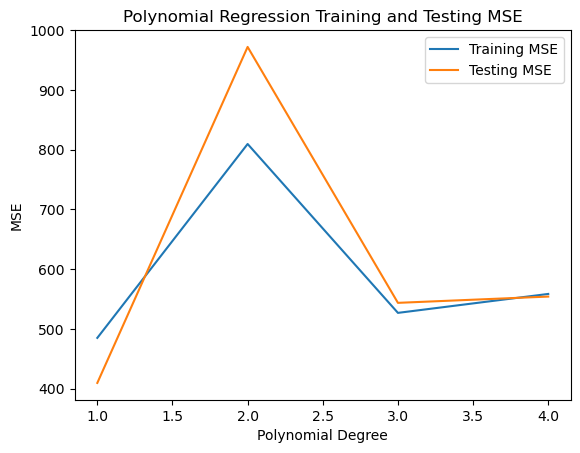

In [16]:
mse_train = [pair[0] for pair in mse_arr]
mse_test = [pair[1] for pair in mse_arr]

# Plot a graph of the training and testing MSE of the model over time
degrees = range(1, len(mse_arr) + 1)
plt.plot(degrees, mse_train, label='Training MSE')
plt.plot(degrees, mse_test, label='Testing MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Polynomial Regression Training and Testing MSE')
plt.legend()
plt.show()

Finally, we can look at a special regression model called Automatic Relevance Determination Regression. The main premise of this method is that it, similar to Linear Regression, fits a line to the data and determines feature relevance by shrinking irrelevant features.

In [17]:
ard = ARDRegression().fit(X_train, y_train_df)
yhat_train, yhat_test = ard.predict(X_train), ard.predict(X_test)

MSE_train, MSE_test = np.mean((y_train.values - yhat_train)**2), np.mean((y_test.values - yhat_test)**2)

print(f'Training Mean Squared Error: {MSE_train}\nTesting Mean Squared Error: {MSE_test}')

Training Mean Squared Error: 386.4592934222615
Testing Mean Squared Error: 290.17133207240596


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Model 1: Analysis/Conclusion

From these models, it can be seen that while they are able to fit the data to some degree, they simply do not fit the data well enough to call it a day. Each of these models have their shortcomings when it comes to predicting training or testing data, or even both.

Thus, it would make sense that we would need a model that either illustrates the level of complexity of the model effectively or is specialized in analyzing time series data. For that, we turn to our next two models: a Neural Network and a RandomForestRegressor.

# Model 2: Neural Network

Next, we will be looking at the neural network architecture and if it may perform effectively in predicting the layoff percentages of companies. We will first try to evaluate the data with a manually created ANN, then move on towards an ANN in which the hyperparameters are modified according to the data to minimize the loss.

In [18]:
def build_nn():
    '''
    Build an Artificial Neural Network model composed of an input layer of 12 nodes with input_dim=51, an output layer of 1
    node, and 3 hidden layers of 12 nodes each, with each layer having a sigmoid activation function applied to it.

    Additionally, compile the model, setting the optimizer to be SGD with an LR of 0.1, measuring the loss with MSE and calculating
    the MSE metric.

    @type model: keras_Sequential() object
    @returns model: a built and compiled Artificial Neural Network model with the given configuration
    '''
    model = Sequential([
        Dense(12, activation='sigmoid', input_dim=51),
        Dense(12, activation='sigmoid'),
        Dense(12, activation='sigmoid'),
        Dense(12, activation='sigmoid'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=SGD(learning_rate=0.1), loss='mse', metrics=['mse'])
    return model

def buildHPmodel(hp):
  '''
  Setup a hyperparameter model that enables us to choose the best to predict our target percentage of employees laid off at a company.

  @type hp: keras_tuner_HyperParameters object
  @param hp: the HyperParameters object that enables us to change our model's hyperparameters

  @type model: keras_Sequential() object
  @returns model: a fully configured Hyperparameter model that enables a user to modify an ANN's hyperparameters to their data
  '''
  model= Sequential([
      Dense(12, activation = 'sigmoid', input_dim = 51),
      Dense(units=hp.Int("units1", min_value=3, max_value=24, step=5),activation=hp.Choice("acttype", ["sigmoid", "relu", "softmax"])),
      Dense(units=hp.Int("units1", min_value=3, max_value=24, step=5),activation=hp.Choice("acttype", ["sigmoid", "relu", "softmax"])),
      Dense(units=hp.Int("units1", min_value=3, max_value=24, step=5),activation=hp.Choice("acttype", ["sigmoid", "relu", "softmax"])),
      Dense(units=1,activation=hp.Choice("acttype", ["sigmoid", "relu", "softmax"])),
])
  learning_rate = hp.Float("lr", min_value=0.05, max_value=0.3, sampling="log")
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
  return model

# This is a tuner that we will be using to perform hyperparameter tuning on the second NN model that we use!
tuner = keras_tuner.GridSearch(
    hypermodel=buildHPmodel,
    objective="val_loss",
    directory="tunerStore",
    project_name="tunerInstance5",
    max_trials=50,
    seed=12,
    executions_per_trial=1,
    tune_new_entries=True,
    allow_new_entries=True,
    max_consecutive_failed_trials=3
)

Reloading Tuner from tunerStore/tunerInstance5/tuner0.json


Now that we have our ANN and tuner definitions set, we can perform a similar process to that of Model 1 in where we will fit the training data to the model, and see its error:

In [19]:
# Let us try out our first neural network to see how well in performs in our predictive task!
nn_regressor = KerasRegressor(model=build_nn, epochs=100, batch_size=5, verbose=0)
hist = nn_regressor.fit(X_train, y_train)
predictions_train, predictions_test = nn_regressor.predict(X_train), nn_regressor.predict(X_test)

print('Training Mean Squared Error:', mean_squared_error(predictions_train, y_train))
print('Testing Mean Squared Error:', mean_squared_error(predictions_test, y_test))

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Mean Squared Error: 786.0688298881963
Testing Mean Squared Error: 584.9784908978622


However, we can improve the model a step further through hyperparameter tuning, which is the practice of changing model hyperparameters, such as the activation functions, number of units per layer, the learning rate, and other factors associated with the neural network architecture, in order to converge to the optimal setup for the problem at hand.

We will be using the GridSearch technique taught to us within the course to search for a specific model configuration that gives us the lowest error.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
X_test_np = np.array(X_test)
y_test_np = np.array(y_test)
X_val_np = np.array(X_val)
y_val_np = np.array(y_val)

#load from tunerStore trial 48
# tuner = keras.models.load_model('tunerStore/tunerInstance3')
#why isnt this working? model = keras.models.load_model('tunerStore/tunerInstance3')

"""TO RUN A NEW GRID SEARCH UNCOMMENT THE LINE BELOW"""
tuner.search(X_train_np, y_train_np, epochs=10, validation_data=(X_val_np, y_val_np), batch_size=15)
# tuner.save('tunerStore/tunerInstance3')

In [ ]:
# Now, let's see how many units, types of activations, and learning rate performs best!
tuner.results_summary()

Results summary
Results in tunerStore/tunerInstance5
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 47 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.07825422900366437
Score: 215.2757110595703

Trial 16 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.13395323057981742
Score: 217.65399169921875

Trial 45 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.11197938216997383
Score: 220.22845458984375

Trial 48 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.06541731153543581
Score: 221.5718994140625

Trial 49 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.13395323057981742
Score: 224.4368896484375

Trial 46 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.0936101501762388
Score: 225.24581909179688

Trial 12 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.11197938216997383
Score: 225.69932556152344

Trial 14 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.07825422900366437
Score: 227.7714080810547

Trial 44 sum

In [22]:
# Now, let us look at the configuration of the best model that we have!
models = tuner.get_best_models(num_models=3)
models[0].summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881 (3.44 KB)

 Trainable params: 881 (3.44 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("For our best model (Trial 13): \n")
print("The MSE for the training data: ", mean_squared_error(y_train, models[0].predict(X_train)))
print("The MSE for the testing data: ", mean_squared_error(y_test, models[0].predict(X_test)))
print("The MSE for the validation data: ", mean_squared_error(y_val, models[0].predict(X_val_np)))
print("\n")
print("For our second best model (Trial 47): \n")
print("The MSE for the training data: ", mean_squared_error(y_train, models[1].predict(X_train)))
print("The MSE for the testing data: ", mean_squared_error(y_test, models[1].predict(X_test)))
print("The MSE for the validation data: ", mean_squared_error(y_val, models[1].predict(X_val_np)))
print("\n")
print("For our third best model (Trial 44): \n")
print("The MSE for the training data: ", mean_squared_error(y_train, models[2].predict(X_train)))
print("The MSE for the testing data: ", mean_squared_error(y_test, models[2].predict(X_test)))
print("The MSE for the validation data: ", mean_squared_error(y_val, models[2].predict(X_val_np)))


For our best model (Trial 13): 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
The MSE for the training data:  394.5410487655632
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
The MSE for the testing data:  327.2802031569785
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
The MSE for the validation data:  215.2757171839336


For our second best model (Trial 47): 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
The MSE for the training data:  395.24783927268356
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
The MSE for the testing data:  333.4995766476978
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
The MSE for the validation data:  217.65400231605165


For our third best model (Trial 44): 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
The MSE for the training data:  394.987272206693
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
The MSE for the testing data:  332.0971994444024
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
The MSE for the validation data:  220.22846199109702


## Hyperparameter Optimization Results
Our best three trials can be seen below.
Trial 13 rendered the best predictions, with an MSE of 220.144. We can see that it found that having 3 units within each layer, using the ReLU activation function, and having a learning rate of 0.0936 was most optimal. Trial 47 and 44 coming in second and third respectively, with different model configurations with a higher error.

```Results summary
Results in tunerStore\tunerInstance5
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 13 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.0936101501762388
Score: 220.14390563964844

Trial 47 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.07825422900366437
Score: 226.53050231933594

Trial 44 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.05
Score: 228.0859375

Trial 20 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.2742923480285484
Score: 228.7980499267578

Trial 11 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.05
Score: 231.3817138671875

Trial 49 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.13395323057981742
Score: 235.16546630859375

Trial 17 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.1602390336065017
Score: 235.59889221191406

Trial 48 summary
Hyperparameters:
units1: 8
acttype: relu
lr: 0.06541731153543581
Score: 240.52723693847656

Trial 12 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.11197938216997383
Score: 245.84762573242188

Trial 15 summary
Hyperparameters:
units1: 3
acttype: relu
lr: 0.06541731153543581
Score: 252.85423278808594
```

## K-Fold Cross Validation: Combatting Overfitting/Underfitting
Based on the results of the best model's MSE: the MSE for the training data:  407.6795840293022, the MSE for the testing data:  344.07788384916205, and the MSE for the validation data:  222.8351758414751. We can conclude that the model is not overfitting since the MSE for the training data is not lower than the testing data.

In [24]:
# Define the KFold parameters
kfold = RepeatedKFold(n_splits=10, n_repeats=1, random_state=1)

# Lists to store MSE scores for each fold
mse_per_fold_training, mse_per_fold_test = list(), list()

y_train_np = y_train.values
y_test_np = y_test.values

j = 0
# KFold Cross Validation
for train, test in kfold.split(X_train, y_train_np):
    # Create and compile the model
    model = build_nn()

    # Fit the model
    estimator = KerasRegressor(model=build_nn, epochs=50, batch_size=5, verbose=0)
    results = estimator.fit(X_train[train], y_train_np[train])

    # Predict and calculate MSE
    predictions_train = results.predict(X_train[train])
    predictions_test = results.predict(X_train[test])

    mse_train = mean_squared_error(y_train_np[train], predictions_train)
    mse_test = mean_squared_error(y_train_np[test], predictions_test)

    # Print metrics for this fold
    # print(f"Fold Accuracy: {acc*100:.2f}%")
    print(f"Fold {j+1} MSE for training: {mse_train:.4f}")
    print(f"Fold {j+1} MSE for testing: {mse_test:.4f}")


    # Append to the lists
    # acc_per_fold.append(acc * 100)
    mse_per_fold_test.append(mse_test)
    mse_per_fold_training.append(mse_train)
    j += 1

# Calculate and print average metrics
print(f"Average MSE for training: {np.mean(mse_per_fold_training):.4f}")
print(f"Average MSE for testing: {np.mean(mse_per_fold_test):.4f}")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 MSE for training: 835.4051
Fold 1 MSE for testing: 501.6252


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 MSE for training: 767.1720
Fold 2 MSE for testing: 1111.5082


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Fold 8 MSE for training: 813.2952
Fold 8 MSE for testing: 695.6669


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 9 MSE for training: 788.7145
Fold 9 MSE for testing: 917.2833


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 10 MSE for training: 785.3571
Fold 10 MSE for testing: 947.5529
Average MSE for training: 801.5570
Average MSE for testing: 802.0271


## Results from Cross Validation
Based on the training and testing MSE of the original model, the Testing Mean Squared Error was 584.9784896957286 and the Training Mean Squared Error was 786.0688282061325. This indicates that the model is not overfitting so the cross validation results do not benefit the model. Since cross validation is primarily helpful when a model is overfitting, cross validation does not benefit the model.

# Model 3: Random Forest Regressor

Finally, we will be seeing if an ensemble-based method would work well for our data. Our model of choice is the Random Forest Regressor, which fits the data to a number of Decision Trees and averages out the results in hopes of a higher accuracy.

In [25]:
# Create a RandomForestRegressor model
rf = RandomForestRegressor(random_state = 42, max_depth = 10, min_samples_split=10)

# Fit the model to the training data
rf.fit(X_train, y_train)

# Try to predict the the training and testing targets given the fitted model
rf_predictions_train = rf.predict(X_train)
rf_predictions_test = rf.predict(X_test)

# Store the MSE between the model's predictions and the ground truth
rf_mse_train = mean_squared_error(rf_predictions_train, y_train)
rf_mse_test = mean_squared_error(rf_predictions_test, y_test)

In [26]:
# Now, let's look at our training and testing MSE!
rf_mse_train, rf_mse_test

(132.08934271775286, 296.4193639478031)

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Parameter grid
n_estimators = [int(x) for x in np.linspace(start=50, stop=150, num=10)]
max_depth = [int(x) for x in np.linspace(10, 110, num=11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]

#bestMSE = None
bestEstimator = 0
bestDepth = 0
bestSamples = 0
mses = []


# grid search!

bestMSE = None
bestEstimator = 0
bestDepth = 0
bestSamples = 0
mses = []

for estimator in n_estimators:
    temp1 = []
    for depth in max_depth:
        temp2 = []
        for samples_split in min_samples_split:
            rf = RandomForestRegressor(n_estimators=estimator, max_depth=depth, min_samples_split=samples_split, random_state = 42)
            rf.fit(X_train, y_train)
            predictions_test = rf.predict(X_test)
            mse_test = mean_squared_error(predictions_test, y_test)
            temp2.append(mse_test)
            if bestMSE is None or mse_test < bestMSE:
                bestMSE = mse_test
                bestEstimator = estimator
                bestDepth = depth
                bestSamples = samples_split
        temp1.append(temp2)
    mses.append(temp1)
            


In [41]:
bestMSE, bestEstimator, bestDepth, bestSamples

(265.30629424069366, 50, 10, 2)

In [43]:
best_rf = RandomForestRegressor(random_state = 42, max_depth = bestDepth, min_samples_split=bestSamples, n_estimators=bestEstimator)
best_rf.fit(X_train, y_train)
best_rf_predictions_train = best_rf.predict(X_train)
best_rf_mse_test = bestMSE
best_rf_mse_train = mean_squared_error(best_rf_predictions_train, y_train)

In [44]:
importance = rf.feature_importances_
importance

array([4.30961887e-01, 9.81425523e-02, 8.40228929e-02, 1.36932521e-01,
       1.42457379e-02, 2.19769665e-02, 1.23024374e-02, 2.24551792e-03,
       3.30580223e-03, 1.08919927e-02, 6.23780931e-06, 3.47714214e-03,
       1.86328188e-03, 1.67136972e-02, 1.46797317e-03, 5.31220893e-05,
       1.79246140e-02, 6.42748801e-04, 6.68043595e-05, 8.24741163e-03,
       2.39979791e-05, 1.81967288e-03, 9.90165586e-04, 3.37263375e-03,
       5.02055454e-04, 9.76102263e-03, 8.76713212e-04, 1.60659806e-02,
       2.53450362e-04, 6.68309122e-04, 8.99575468e-05, 6.67622945e-03,
       4.50127671e-02, 6.89044346e-03, 4.13320572e-04, 7.81163774e-04,
       7.28909612e-03, 8.90797049e-03, 6.10796095e-03, 1.62224949e-03,
       1.19704904e-03, 4.77487304e-04, 8.59308701e-04, 1.39357968e-03,
       7.85411866e-06, 1.05413325e-04, 3.86117040e-03, 2.48828738e-03,
       1.80570368e-03, 4.17897389e-03, 8.67124176e-06])

In [45]:
date_layoffs_imp = importance[0]
stock_delta_imp = importance[1]
company_size_imp = importance[2]
money_raised_imp = importance[3]
industry_imp = sum([importance[i] for i in range(4, 33)])
stage_imp = sum([importance[i] for i in range(33, 37)])
region_imp = sum([importance[i] for i in range(37, 51)])

In [46]:
importances = [date_layoffs_imp, stock_delta_imp, company_size_imp, money_raised_imp, industry_imp, stage_imp, region_imp]
categories = ['Date Layoffs', 'Stock Delta', 'Company Size', 'Money Raised', 'Industry', 'Stage', 'Region']

([<matplotlib.patches.Wedge at 0x151810e90>,
 [Text(0.23671251912727714, 1.0742286457213932, 'Date Layoffs'),
  Text(-1.0913548652274436, 0.13763923185047344, 'Stock Delta'),
  Text(-0.9920015556241645, -0.4753240091129817, 'Company Size'),
  Text(-0.45836810082454543, -0.9999493407900719, 'Money Raised'),
  Text(0.6512074453537576, -0.886526290143633, 'Industry'),
  Text(1.064212796012087, -0.2783004218540388, 'Stage'),
  Text(1.0940861343103647, -0.11391018703260361, 'Region')])

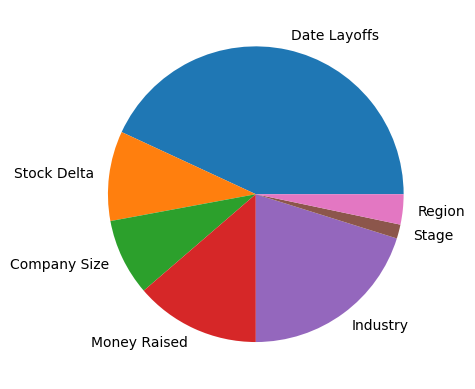

In [47]:
plt.pie(importances, labels=categories)

Figure above shows importance of each feature in prediction

For constant depth and min number of samples, we can plot the MSE vs the number of estimators. Here, we set depth and min number of samples as the best values found by Grid Search. Clearly, we can see that there is an optimal number of estimators at `n_estimators = 94` where the MSE is minimized.

In [34]:
from sklearn.metrics import mean_squared_error

# Linear Regression
linreg_y_pred = linreg.predict(X_test)
linreg_results = pd.DataFrame({
    "Actual": y_test.values.flatten(),
    "Predicted": linreg_y_pred.flatten()
})
linreg_results["Model"] = "Linear Regression"

# ARD Regression
ard_y_pred = ard.predict(X_test)
ard_results = pd.DataFrame({
    "Actual": y_test.values.flatten(),
    "Predicted": ard_y_pred.flatten()
})
ard_results["Model"] = "ARD Regression"

# Neural Network
nn_y_pred = nn_regressor.predict(X_test)
nn_results = pd.DataFrame({
    "Actual": y_test.values.flatten(),
    "Predicted": nn_y_pred.flatten()
})
nn_results["Model"] = "Neural Network"

# Random Forest (Best Model)
rf_y_pred = best_rf.predict(X_test)
rf_results = pd.DataFrame({
    "Actual": y_test.values.flatten(),
    "Predicted": rf_y_pred.flatten()
})
rf_results["Model"] = "Random Forest"

# Combine all
all_results = pd.concat([linreg_results, ard_results, nn_results, rf_results], ignore_index=True)


In [35]:
all_results.to_csv("/Applications/Dissertation/tech_layoffs_ml/datasets/all_model_predictions.csv", index=False)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_scores = []

for model in all_results['Model'].unique():
    model_df = all_results[all_results['Model'] == model]
    mae = mean_absolute_error(model_df['Actual'], model_df['Predicted'])
    mse = mean_squared_error(model_df['Actual'], model_df['Predicted'])
    r2 = r2_score(model_df['Actual'], model_df['Predicted'])
    model_scores.append({
        'Model': model,
        'MAE': mae,
        'MSE': mse,
        'R2 Score': r2
    })

results_df = pd.DataFrame(model_scores).sort_values(by='R2 Score', ascending=False)
print(results_df)

               Model        MAE         MSE  R2 Score
3      Random Forest  10.860601  265.306294  0.217674
0  Linear Regression  12.484798  333.839601  0.015586
1     ARD Regression  12.221891  341.257426 -0.006288
2     Neural Network  18.529978  682.485138 -1.012488
